In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
from sklearn.model_selection import train_test_split ,KFold ,cross_validate , GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression ,Ridge ,Lasso
from sklearn.ensemble import RandomForestRegressor , HistGradientBoostingClassifier
from sklearn.metrics import mean_squared_error , r2_score ,root_mean_squared_error ,mean_absolute_error

In [3]:
CSV_PATH = 'housing.csv'
TARGET_COL = 'median_house_value'

# Dataset Link 
https://www.kaggle.com/datasets/camnugent/california-housing-prices

In [4]:
df = pd.read_csv(CSV_PATH)

In [5]:
#df.shape
#df.head()
#df.info()
#df.isna().sum()                    total_bedrooms - 207
#df.duplicated().sum()

In [6]:
num_colm = df.select_dtypes(include=[np.number]).columns.to_list()
cate_colm = df.select_dtypes(include=['object']).columns.to_list()

/var/folders/mh/ftt5wfxx59d5_q9q45n4qhpm0000gn/T/ipykernel_89788/3325510305.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cate_colm = df.select_dtypes(include=['object']).columns.to_list()


In [7]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

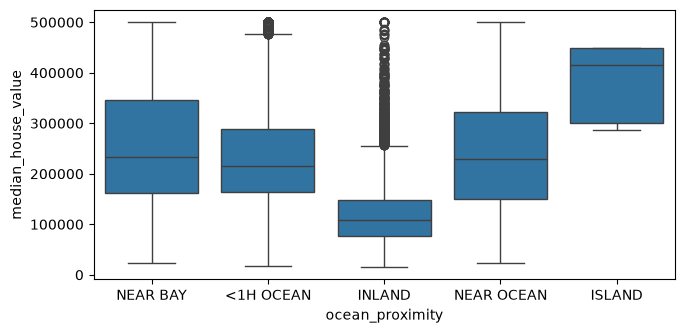

In [8]:
#df.describe()

plt.figure(figsize=(7.5, 3.5))
sns.boxplot(x='ocean_proximity', y=TARGET_COL, data=df)
plt.xlabel('ocean_proximity')
plt.ylabel(TARGET_COL)
plt.show()

In [9]:
df[cate_colm].value_counts()

ocean_proximity
<1H OCEAN          9136
INLAND             6551
NEAR OCEAN         2658
NEAR BAY           2290
ISLAND                5
Name: count, dtype: int64

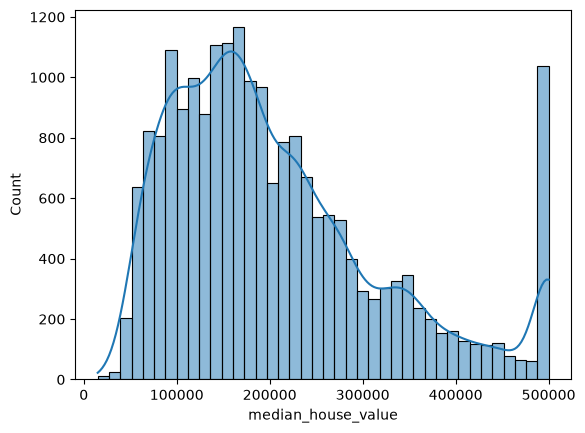

In [10]:
sns.histplot(df[TARGET_COL], bins=40, kde=True)
plt.show()

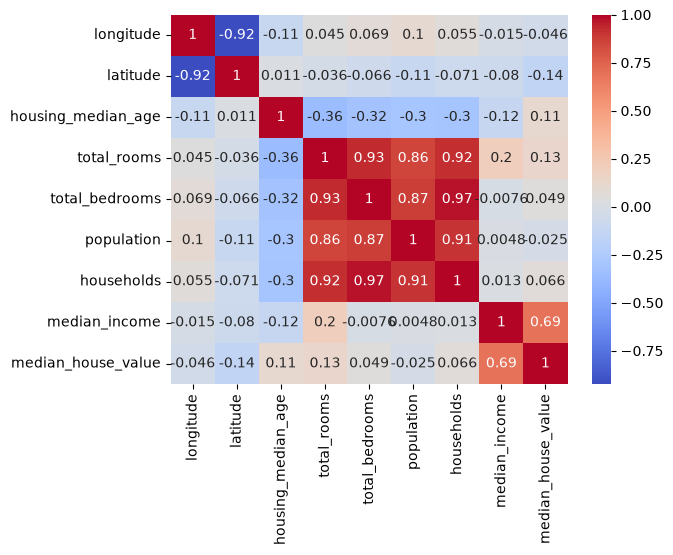

In [11]:
sns.heatmap(df[num_colm].corr(), annot=True, cmap='coolwarm')
plt.show()

In [12]:
corr_target =df[num_colm].corr()[TARGET_COL].sort_values(ascending=False)
corr_target

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049457
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

In [13]:
X = df.drop(columns = [TARGET_COL])
Y =df[TARGET_COL]

In [14]:
X_train , X_test ,y_train ,y_test =train_test_split(X ,Y , test_size=.2 ,random_state=42 )

In [15]:
num_feature = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_feature = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

In [16]:
num_transformer =Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy="median")),
        ('scaler', StandardScaler())
    ]
)

cat_transformer =Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy="most_frequent")),
        ('onehot' ,OneHotEncoder(handle_unknown='ignore'))
    ]
)

prepocess = ColumnTransformer(
    transformers= [
        ("num", num_transformer ,num_feature),
        ("cate",cat_transformer, cat_feature)
    ]
)

In [17]:
base_pipe = Pipeline(
    steps=[
        ('prepocess',prepocess),
        ('model', LinearRegression())

    ]
)

In [19]:
base_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prepocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cate', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. 

In [26]:
y_pred =base_pipe.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"R2  : {r2:.2f}")

RMSE: 70060.52
MAE : 50670.74
MSE : 4908476721.16
R2  : 0.63
